<font size = "3">

**(Q1)** The bubble sort algorithm can be modified to "bubble" in both directions. The first pass moves "up" the list, and the maximum element "bubbles" to the top. The second pass moves "down" the list, and the minimum element "bubbles" to the bottom. This alternating pattern continues until no more passes are necessary. 

Write a function that implements this algorithm.

In [1]:
def bubble_up_down(lst):
    n = len(lst)
    if n <= 1:
        return
    passes, r = divmod(n, 2)
    for p in range(passes-1):
        for i in range(p, n-1-p):
            if lst[i] > lst[i+1]:
                lst[i], lst[i+1] = lst[i+1], lst[i]
        for j in range(n-2-p, p, -1):
            if lst[j] < lst[j-1]:
                lst[j], lst[j-1] = lst[j-1], lst[j]
    
    # last pass
    p = passes - 1
    for i in range(p, n-1-p):
        if lst[i] > lst[i+1]:
            lst[i], lst[i+1] = lst[i+1], lst[i]
    if not r:
        return
    for j in range(n-2-p, p, -1):
        if lst[j] < lst[j-1]:
            lst[j], lst[j-1] = lst[j-1], lst[j]

In [2]:
# test code 

import random 
n = 115
lst = random.choices(range(100), k=n)
sorted_lst = sorted(lst[:])

bubble_up_down(lst)

print(lst == sorted_lst)

True


<font size = "3">

**(Q2)** The implementation of the merge sort algorithm we saw had two deficiencies:

1. It used **slicing** as follows:

```python
        left_half = a_list[:mid]
        right_half = a_list[mid:]
        merge_sort(left_half)
        merge_sort(right_half)
```
Each slicing operation incurs an additional $O(k)$ cost, where $k$ is the size of the slice.

2. Once the slicing operation is executed, we need extra memory to store the two halves of the list independently of the original list. This increases the algorithm's *space* complexity.

Implement a version of merge sort that does not use slicing and sorts the list **in-place**. Some starter code is provided below for you to complete.

What sorting algorithm should be used for merging two sorted sub-lists?

In [3]:
def merge_sort(a_list):
    merge_sort_helper(a_list, 0, len(a_list))

def merge_sort_helper(lst, start_index, end_index):
    local_len = end_index - start_index
    # 1. Base case of recursion
    if local_len == 1:
        return

    # 2. Two recursive calls to merge_sort_helper
    mid = local_len // 2
    # print("Splitting:", lst[start_index:end_index])
    merge_sort_helper(lst, start_index, start_index+mid)
    merge_sort_helper(lst, start_index+mid, end_index)

    # 3. Merge the two halfs of the list (in-place!)
    # print("Merging:", lst[start_index:start_index+mid], lst[start_index+mid:end_index])
    j = start_index + mid 
    i = start_index
    while j < end_index:
        cur_val = lst[j]
        insert = j
        for k in range(j, i, -1):
            if lst[k-1] > cur_val:
                lst[k] = lst[k-1]
                insert = k-1
            else:
                insert = k
                break
        lst[insert] = cur_val
        j +=1 
        i = k

In [ ]:
# test code 

import random 
n = 115
lst = random.choices(range(100), k=n)

sorted_lst = sorted(lst[:])

merge_sort(lst)

print(lst == sorted_lst)


True


<font size = "3">

**(Q3)** One way to improve the quicksort algorithm is to enforce a "partition limit". Instead of treating $n = 1$ as the base case of the recursion, we choose a short length $m > 1$ for the base case. When the length of the sub-list is $\leq m$, we end the recursion and sort it directly using insertion sort.

- Implement this version of quicksort where the partition limit is included as an additional input parameter. For $m = 1$, it reduces to the original quicksort.

- Perform benchmark tests on large lists of randomly generated integers. Vary both the size of the lists ($n$) and the partition limit ($m$) and see how performance is affected, in terms of time.

In [5]:
def quick_sort(a_list, m):
    quick_sort_helper(a_list, 0, len(a_list) - 1, m)

def quick_sort_helper(a_list, first, last, m):
    if first + (m-1) < last:
        split = partition(a_list, first, last)
        quick_sort_helper(a_list, first, split - 1, m)
        quick_sort_helper(a_list, split + 1, last, m)
    else:
        insertion_sort(a_list, first, last)

def insertion_sort(a_list, first, last):
    for p in range(first+1, last+1):
        next_val = a_list[p]
        insert = first 
        for pos in range(p, first, -1):
            if a_list[pos-1] <= next_val:
                insert = pos
                break 
            lst[pos] = lst[pos-1]
        lst[insert] = next_val

    
def partition(a_list, first, last):
    pivot_val = a_list[first]
    left_mark = first + 1
    right_mark = last
    done = False

    while not done:
        while left_mark <= right_mark and a_list[left_mark] <= pivot_val:
            left_mark = left_mark + 1
        while left_mark <= right_mark and a_list[right_mark] >= pivot_val:
            right_mark = right_mark - 1
        if right_mark < left_mark:
            done = True
        else:
            a_list[left_mark], a_list[right_mark] = (
                a_list[right_mark],
                a_list[left_mark],
            )
    a_list[first], a_list[right_mark] = a_list[right_mark], a_list[first]

    return right_mark

In [6]:
# test code 

import random 
n = 115
m = 12
lst = random.choices(range(100), k=n)
sorted_lst = sorted(lst[:])

quick_sort(lst, m)

print(lst == sorted_lst)


True


In [7]:
from timeit import default_timer
import numpy as np
import random

n_vals = [100, 200, 400, 800, 1600]
m_vals = [1, 5, 10, 20, 30, 40, 50]
# m_vals = [1, 5, 10, 25, 50]

shape = (len(m_vals), len(n_vals))
time_arr = np.zeros(shape)

repeats = 20

for row, m in enumerate(m_vals):
    total_time = 0
    for col, n in enumerate(n_vals):
        for _ in range(repeats):
            lst = list(range(n))
            random.shuffle(lst)
            start = default_timer()
            quick_sort(lst, m)
            stop = default_timer()
            total_time += stop - start 
        time_arr[row, col] = total_time/repeats


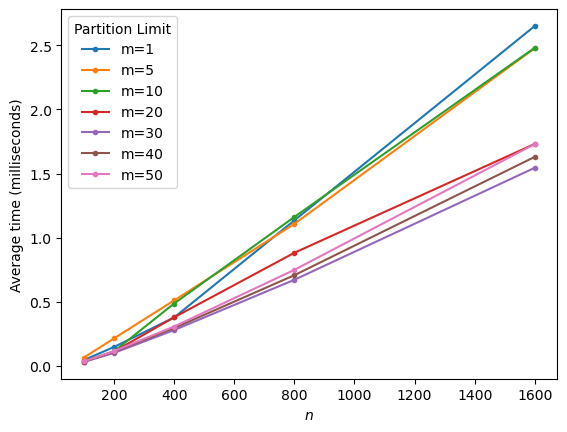

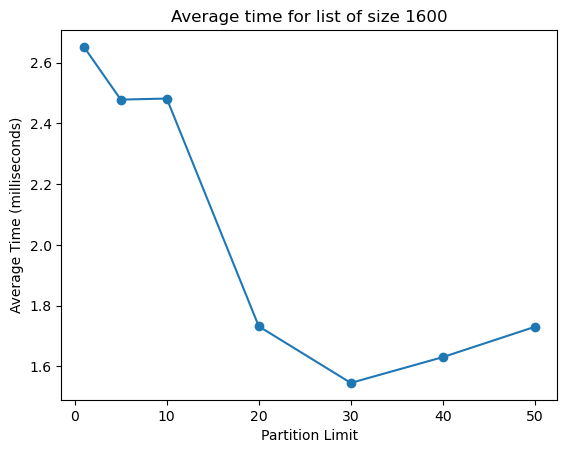

In [8]:
import matplotlib.pyplot as plt 
for row, m in enumerate(m_vals):
    plt.plot(n_vals, 1000*time_arr[row,:], '.-', label=f'm={m}')

plt.legend(title = "Partition Limit")
plt.xlabel('$n$')
plt.ylabel('Average time (milliseconds)')
plt.show()

plt.plot(m_vals, 1000*time_arr[:,-1], 'o-')
plt.xlabel("Partition Limit")
plt.ylabel("Average Time (milliseconds)")
plt.title(f"Average time for list of size {n_vals[-1]}")
plt.show()

<font size = "3">

**(Q4)**

1. Implement a variant of quicksort where the **last** element of the list is used as the pivot value.

2. Implement a variant of quicksort where the **middle** element of the list is used as the pivot value.

In [9]:
# 1. Version 1: rewrite partition subroutine with pivot element at the end

def quick_sort(a_list):
    quick_sort_helper(a_list, 0, len(a_list) - 1)

def quick_sort_helper(a_list, first, last):
    if first < last:
        split = partition(a_list, first, last)
        quick_sort_helper(a_list, first, split - 1)
        quick_sort_helper(a_list, split + 1, last)

def partition(a_list, first, last):
    pivot_val = a_list[last]
    left_mark = first
    right_mark = last-1
    done = False

    while not done:
        while left_mark <= right_mark and a_list[left_mark] <= pivot_val:
            left_mark = left_mark + 1
        while left_mark <= right_mark and a_list[right_mark] >= pivot_val:
            right_mark = right_mark - 1
        if right_mark < left_mark:
            done = True
        else:
            a_list[left_mark], a_list[right_mark] = (
                a_list[right_mark],
                a_list[left_mark],
            )
    a_list[last], a_list[right_mark+1] = a_list[right_mark+1], a_list[last]

    return right_mark+1

In [10]:
# test code 

import random 
n = 115
lst = random.choices(range(100), k=n)
sorted_lst = sorted(lst[:])

merge_sort(lst)

print(lst == sorted_lst)


True


In [11]:
# 1. version 2: swap last and first element, then just use standard partition
def quick_sort(a_list):
    quick_sort_helper(a_list, 0, len(a_list) - 1)

def quick_sort_helper(a_list, first, last):
    if first < last:
        split = partition(a_list, first, last)
        quick_sort_helper(a_list, first, split - 1)
        quick_sort_helper(a_list, split + 1, last)

def partition(a_list, first, last):
    a_list[first], a_list[last] = a_list[last], a_list[first]

    pivot_val = a_list[first]
    left_mark = first + 1
    right_mark = last
    done = False

    while not done:
        while left_mark <= right_mark and a_list[left_mark] <= pivot_val:
            left_mark = left_mark + 1
        while left_mark <= right_mark and a_list[right_mark] >= pivot_val:
            right_mark = right_mark - 1
        if right_mark < left_mark:
            done = True
        else:
            a_list[left_mark], a_list[right_mark] = (
                a_list[right_mark],
                a_list[left_mark],
            )
    a_list[first], a_list[right_mark] = a_list[right_mark], a_list[first]

    return right_mark

In [12]:
# test code 

import random 
n = 115
lst = random.choices(range(100), k=n)
sorted_lst = sorted(lst[:])

merge_sort(lst)

print(lst == sorted_lst)


True


In [13]:
# 2. Swap middle element with first element, then do standard partition

def quick_sort(a_list):
    quick_sort_helper(a_list, 0, len(a_list) - 1)


def quick_sort_helper(a_list, first, last):
    if first < last:
        split = partition(a_list, first, last)
        quick_sort_helper(a_list, first, split - 1)
        quick_sort_helper(a_list, split + 1, last)


def partition(a_list, first, last):
    mid = (last - first + 1) // 2
    a_list[first + mid], a_list[first] = a_list[first], a_list[first + mid]
    pivot_val = a_list[first]
    left_mark = first + 1
    right_mark = last
    done = False

    while not done:
        while left_mark <= right_mark and a_list[left_mark] <= pivot_val:
            left_mark = left_mark + 1
        while left_mark <= right_mark and a_list[right_mark] >= pivot_val:
            right_mark = right_mark - 1
        if right_mark < left_mark:
            done = True
        else:
            a_list[left_mark], a_list[right_mark] = (
                a_list[right_mark],
                a_list[left_mark],
            )
    a_list[first], a_list[right_mark] = a_list[right_mark], a_list[first]

    return right_mark

In [14]:
# test code 

import random 
n = 115
lst = random.choices(range(100), k=n)
sorted_lst = sorted(lst[:])

merge_sort(lst)

print(lst == sorted_lst)


True


<font size = "3">

**(Q5)** Implement quicksort where the "median of three" method is used for selecting the pivot. That is, compare the first, middle, and last elements of a list and use the median as the pivot value.

In [15]:
def quick_sort(a_list):
    quick_sort_helper(a_list, 0, len(a_list) - 1)


def quick_sort_helper(a_list, first, last):
    if first < last:
        split = partition(a_list, first, last)
        quick_sort_helper(a_list, first, split - 1)
        quick_sort_helper(a_list, split + 1, last)


def partition(a_list, first, last):
    mid = (last - first + 1) // 2
    # move max to end
    if lst[first] > lst[first + mid]:
        lst[first], lst[first + mid] = lst[first+mid], lst[first]
    if lst[first+mid] > lst[last]:
        lst[last], lst[first + mid] = lst[first+mid], lst[last]
    
    # move minimum to middle (i.e. median to beginning)
    if lst[first] < lst[first + mid]:
        lst[first], lst[first + mid] = lst[first+mid], lst[first]

    # then do original partitioning
    pivot_val = a_list[first]
    left_mark = first + 1
    right_mark = last
    done = False

    while not done:
        while left_mark <= right_mark and a_list[left_mark] <= pivot_val:
            left_mark = left_mark + 1
        while left_mark <= right_mark and a_list[right_mark] >= pivot_val:
            right_mark = right_mark - 1
        if right_mark < left_mark:
            done = True
        else:
            a_list[left_mark], a_list[right_mark] = (
                a_list[right_mark],
                a_list[left_mark],
            )
    a_list[first], a_list[right_mark] = a_list[right_mark], a_list[first]

    return right_mark

In [16]:
# test code 

import random 
n = 115
lst = random.choices(range(100), k=n)
sorted_lst = sorted(lst[:])

merge_sort(lst)

print(lst == sorted_lst)


True
